In [1]:
using PyPlot
using JLD2
using Statistics
using ProgressBars
import PhysicalConstants.CODATA2018: c_0
using Unitful
using MAT
using HDF5
using Images, ImageMorphology

In [2]:
function load_crop_imgs(filenames, pathdir, x_crop, y_crop)
    imgs_atoms, imgs_bkg, imgs_dark, amplitude_laser = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"])), x_crop, y_crop)
            img_bkg = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"])), x_crop, y_crop)
            img_dark = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"])), x_crop, y_crop)
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(amplitude_laser, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, amplitude_laser
end

function crop_img(img, x_crop, y_crop)
    return img[y_crop, x_crop]
end

function load_t_exp(filepath)
    h5open(filepath, "r") do file
        return read_attribute(file["globals"], "vert_blue_imaging_pulse_duration_high")
    end
end


function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, Amplitude_laser, t_exp)
    """ Computes ODs for images not organised in datasets """
    ODs = zeros((size(imgs_atoms)[1], size(imgs_atoms[1])...))
    for i in 1:size(imgs_atoms)[1]
        OD = (imgs_atoms[i] .- imgs_dark[i]) ./ (imgs_bkg[i] .- imgs_dark[i])

        OD[OD .<= 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
        OD .= -log10.(OD)
        OD[isnan.(OD)] .= 0 # Map Nan values to 0
        OD[OD .== -Inf] .= 0 # Some values are send to -Inf

        # For high intensity, modified OD formula
        if Amplitude_laser[i] >= 0.3 # Corresponds more or less to a saturation intensity bigger than 1
            OD .+= (imgs_bkg[i] .- imgs_atoms[i]) / (7000*t_exp/5e-6)
        end
        ODs[i, :, :] = OD
    end
    return ODs
end

compute_OD_high_low_intensity (generic function with 1 method)

In [3]:
pathdir = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°

x_crop = [1300:1700;]
y_crop = [1750:2150;]

shots = 380

mask_dilation = 11

λ = 421e-9
Γ = 2.02e8 # In Hz
ω0 = 2π*ustrip(c_0)/λ
Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2/atom

size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

### Crop images

In [4]:
# files_path = readdir(pathdir)
# Imgs_atoms_crop, Imgs_bkg_crop, Imgs_dark_crop, Amplitude_laser = load_crop_imgs(files_path, pathdir, x_crop, y_crop)
# τ_exp = load_t_exp(joinpath(pathdir, readdir(pathdir)[1])); # In s, if the exposure time is the same for all images;

In [5]:
@load "Saved_exp_data/Imgs_croped_2026_02_11_0001.jld2" Imgs_atoms_crop Imgs_bkg_crop Imgs_dark_crop Amplitude_laser τ_exp;

### Check validity of masks

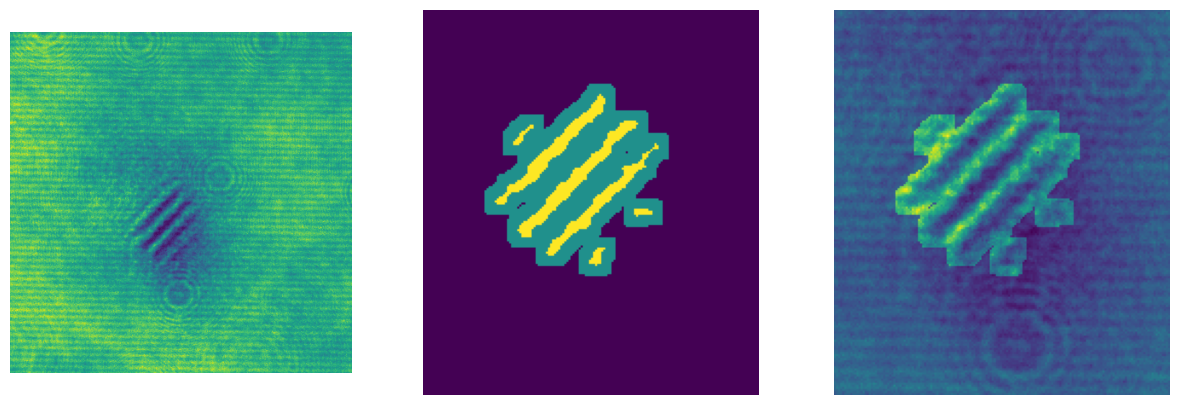

In [7]:
i = 9
file = matopen("Saved_masks/$i.mat")
mask = read(file, "binaryMask")'
xStart = read(file, "xStart")
yStart = read(file, "yStart")
close(file)

close("all")
fig, axs = subplots(1, 3, figsize=(15, 5))

axs[1].imshow(Imgs_atoms_crop[i])

se = ones(Bool, mask_dilation, mask_dilation)
mask_dilated = dilate(mask, se)

axs[2].imshow(mask .+ mask_dilated)

img_cropped = Imgs_atoms_crop[i][Int(xStart):size(mask)[1]+Int(xStart)-1, Int(yStart):size(mask)[2]+Int(yStart)-1]

axs[3].imshow(img_cropped .* mask_dilated .+ img_cropped)

axs[1].axis("off"), axs[2].axis("off"), axs[3].axis("off")

# pygui(true); show()
pygui(false);

### Load masks

In [17]:
masks, xStarts, yStarts = [], [], []

for i = 1:length(Imgs_atoms_crop)
    file = matopen("Saved_masks/$i.mat")
    push!(masks, read(file, "binaryMask")')
    push!(xStarts, read(file, "xStart")')
    push!(yStarts, read(file, "yStart")')
    close(file)
end

### Compute intensities

In [18]:
Iatoms_masked, Ibkg_masked, Idark_masked = zeros(length(Imgs_atoms_crop)), zeros(length(Imgs_atoms_crop)), zeros(length(Imgs_atoms_crop))
se = ones(Bool, mask_dilation, mask_dilation)

# Convertion factor to go from electrons to photons
if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
end

for i = ProgressBar(1:size(Imgs_atoms_crop)[1])
    if length(τ_exp) > 1
        Convertion_factor = 0.107 / (0.85 * τ_exp[i])
    end
    mask = masks[i]
    mask_dilated = dilate(mask, se)

    Iatoms_masked[i] = sum(Imgs_atoms_crop[i][Int(xStarts[i]):size(mask)[1]+Int(xStarts[i])-1, Int(yStarts[i]):size(mask)[2]+Int(yStarts[i])-1] .* mask_dilated)  * Convertion_factor / (length(mask_dilated[mask_dilated.>0])*size_pxl^2)
    Ibkg_masked[i] = sum(Imgs_bkg_crop[i][Int(xStarts[i]):size(mask)[1]+Int(xStarts[i])-1, Int(yStarts[i]):size(mask)[2]+Int(yStarts[i])-1] .* mask_dilated)  * Convertion_factor / (length(mask_dilated[mask_dilated.>0])*size_pxl^2)
    Idark_masked[i] = sum(Imgs_dark_crop[i][Int(xStarts[i]):size(mask)[1]+Int(xStarts[i])-1, Int(yStarts[i]):size(mask)[2]+Int(yStarts[i])-1] .* mask_dilated)  * Convertion_factor / (length(mask_dilated[mask_dilated.>0])*size_pxl^2)
end

0.0%┣                                            ┫ 0/380 [00:06<-36:-20, -6s/it]
0.3%┣                                          ┫ 1/380 [00:06<Inf:Inf, InfGs/it]
0.8%┣▍                                              ┫ 3/380 [00:06<20:21, 3s/it]
2.4%┣█▏                                             ┫ 9/380 [00:07<05:03, 1it/s]
2.9%┣█▎                                            ┫ 11/380 [00:07<04:05, 2it/s]
5.3%┣██▍                                           ┫ 20/380 [00:07<02:07, 3it/s]
6.1%┣██▉                                           ┫ 23/380 [00:07<01:50, 3it/s]
7.6%┣███▌                                          ┫ 29/380 [00:07<01:25, 4it/s]
9.7%┣████▌                                         ┫ 37/380 [00:07<01:05, 5it/s]
10.5%┣████▊                                        ┫ 40/380 [00:07<01:00, 6it/s]
12.1%┣█████▌                                       ┫ 46/380 [00:07<00:52, 6it/s]
13.9%┣██████▎                                      ┫ 53/380 [00:07<00:44, 7it/s]
15.3%┣██████▉               

### Reorganize the data per datasets

In [19]:
nbr_amp_laser = length(unique(Amplitude_laser))
nbr_repetition = Integer(length(Imgs_atoms_crop)/nbr_amp_laser)

I_atoms_masked_ds, I_bkg_masked_ds, I_dark_masked_ds = zeros((nbr_amp_laser, nbr_repetition)), zeros((nbr_amp_laser, nbr_repetition)), zeros((nbr_amp_laser, nbr_repetition))

for i in 1:length(Iatoms_masked)
        idx_line = findfirst(==(Amplitude_laser[i]), unique(Amplitude_laser))
        idx_row = floor(Int64, (i-1)/nbr_amp_laser+1)
        I_atoms_masked_ds[idx_line, idx_row] = Iatoms_masked[i]
        I_bkg_masked_ds[idx_line, idx_row] = Ibkg_masked[i]
        I_dark_masked_ds[idx_line, idx_row] = Idark_masked[i]
end

### Compute mean/std


In [20]:
Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms = zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser)
Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms = zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser)

for i = 1:nbr_amp_laser
    atoms, bkg, dark, bkg_atoms = [], [], [], []
    for j = 1:size(I_atoms_masked_ds)[2]
        push!(atoms, I_atoms_masked_ds[i, j]), push!(bkg, I_bkg_masked_ds[i, j]), push!(dark, I_dark_masked_ds[i, j]), push!(bkg_atoms, I_bkg_masked_ds[i, j]-I_atoms_masked_ds[i, j])
    end
    if length(atoms) > 0
        Mean_atoms[i], Mean_bkg[i], Mean_dark[i], Mean_bkg_atoms[i] = mean(atoms), mean(bkg), mean(dark), mean(bkg_atoms)
        Std_atoms[i], Std_bkg[i], Std_dark[i], Std_bkg_atoms[i] = std(atoms), std(bkg), std(dark), std(bkg_atoms)
    end
end

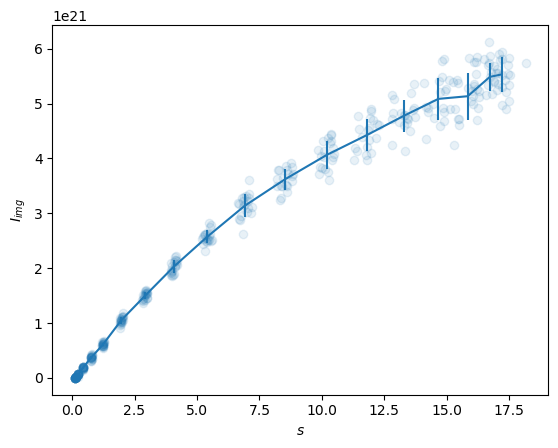

PyObject Text(28.299999999999997, 0.5, '$I_{img}$')

In [21]:
line_stripe_90, = errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms)

for i = 1:size(I_atoms_masked_ds)[1]
    for j = 1:size(I_atoms_masked_ds)[2]
        scatter(I_bkg_masked_ds[i, j]/Isat, I_bkg_masked_ds[i, j]-I_atoms_masked_ds[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

### Save data

In [22]:
@save "Saved_exp_data/Intensity_integrated_mask_"*join(split(pathdir, "/")[3:end], "_")*".jld2" I_atoms_masked_ds I_bkg_masked_ds I_dark_masked_ds Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

### Compute OD for atom nbr

In [23]:
ODs = compute_OD_high_low_intensity(Imgs_atoms_crop, Imgs_bkg_crop, Imgs_dark_crop, Amplitude_laser, τ_exp);

In [24]:
@save "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs

### Check masks

In [25]:
if !isdir("Images")
    mkdir("Images")
end
if !isdir("Images/Mask_"*join(split(pathdir, "/")[3:end], "_"))
    mkdir("Images/Mask_"*join(split(pathdir, "/")[3:end], "_"))
end


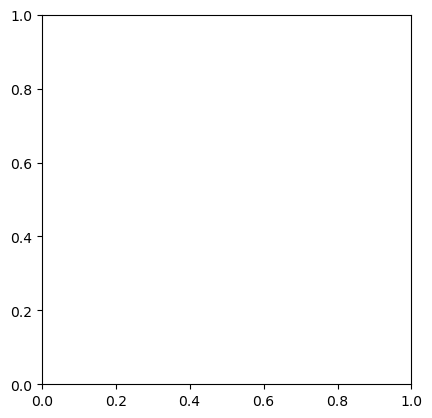

In [26]:
fig, ax = plt.subplots()
se = ones(Bool, mask_dilation, mask_dilation)

for i = 1:size(Imgs_atoms_crop)[1]
    mask = masks[i]
    mask_dilated = dilate(mask, se)

    OD_croped_mask = ODs[i, Int(xStarts[i]):size(mask)[1]+Int(xStarts[i])-1, Int(yStarts[i]):size(mask)[2]+Int(yStarts[i])-1]

    ax.imshow(OD_croped_mask .* mask_dilated .+ OD_croped_mask)
    savefig("Images/Mask_"*join(split(pathdir, "/")[3:end], "_")*"/$i.png")
    ax.clear()
end

### Brouillons

In [27]:
# function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, Amplitude_laser, t_exp)
#     ODs = zeros(size(imgs_atoms))
#     for i in ProgressBar(1:size(imgs_atoms)[1])
#         for j = 1:size(imgs_atoms)[2]
#             OD = (imgs_atoms[i, j, :, :] .- imgs_dark[i, j, :, :]) ./ (imgs_bkg[i, j, :, :] .- imgs_dark[i, j, :, :])

#             OD[OD .<= 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
#             OD .= -log10.(OD)
#             OD[isnan.(OD)] .= 0 # Map Nan values to 0
#             OD[OD .== -Inf] .= 0 # Some values are send to -Inf

#             # For high intensity, modified OD formula
#             if Amplitude_laser[i] >= 0.3 # Corresponds more or less to a saturation intensity bigger than 1
#                 OD .+= (imgs_bkg[i, j, :, :] .- imgs_atoms[i, j, :, :]) / (7000*t_exp/5e-6)
#             end
#             ODs[i, j, :, :] .= OD
#         end
#     end
#     return ODs
# end